In [1]:
# I cannot pip install on the Hub
import sys
import os
import importlib
import json
import numpy as np
from het_cov import fibers
importlib.reload(fibers)

# Determine if we are on the Hub by checking for a specific environment variable
if 'JUPYTERHUB_USER' in os.environ:
    data_dir = '/home/jovyan/work/hetdex/data/'
else:
    data_dir = '/work/06536/qezlou/hetdex/data/'

config={ "masking":{
    "bad_fibers": True,
    "bad_pixels": True,
    "strong_continuum": True,
    "top_varying_pixels": False,
    "top_percent": 5.0,
    "top_fiber_frac":0.3
    },
    "cov_options": {
        "per": "shot",
        "method": "full",
        "l": 100
    },
    "calfib_type": "calfib",
    "normalize": False       
}

fibs = fibers.Fibers(data_dir, config=config)

Populating dustmaps config with /home/jovyan/Hobby-Eberly-Telesco/hdr3/calib/dustmaps
Fibers | 10/09/2025 06:33:45 PM | INFO  |  we have 6771 shotids in total
Fibers | 10/09/2025 06:33:45 PM | INFO  |  Masking options: {'bad_fibers': True, 'bad_pixels': True, 'strong_continuum': True, 'top_varying_pixels': False, 'top_percent': 5.0, 'top_fiber_frac': 0.3}
Fibers | 10/09/2025 06:33:45 PM | INFO  |  Covariance options: {'per': 'shot', 'method': 'full', 'l': 100}
Fibers | 10/09/2025 06:33:45 PM | INFO  |  Flux, calfib_type: calfib


In [2]:
fibs_tab = fibs.get_fibers_one_shot(fibs.shotids_list[-10], keep_calfibe=True)

Fibers | 10/09/2025 06:33:53 PM | INFO  |  Total fibers: 18816
Fibers | 10/09/2025 06:33:53 PM | INFO  |  Good fibers: 11079, Fraction of good pixels 0.967123180973709
Fibers | 10/09/2025 06:33:54 PM | INFO  |   Remaining fraction after removing continuum sources 0.7135120498239913 


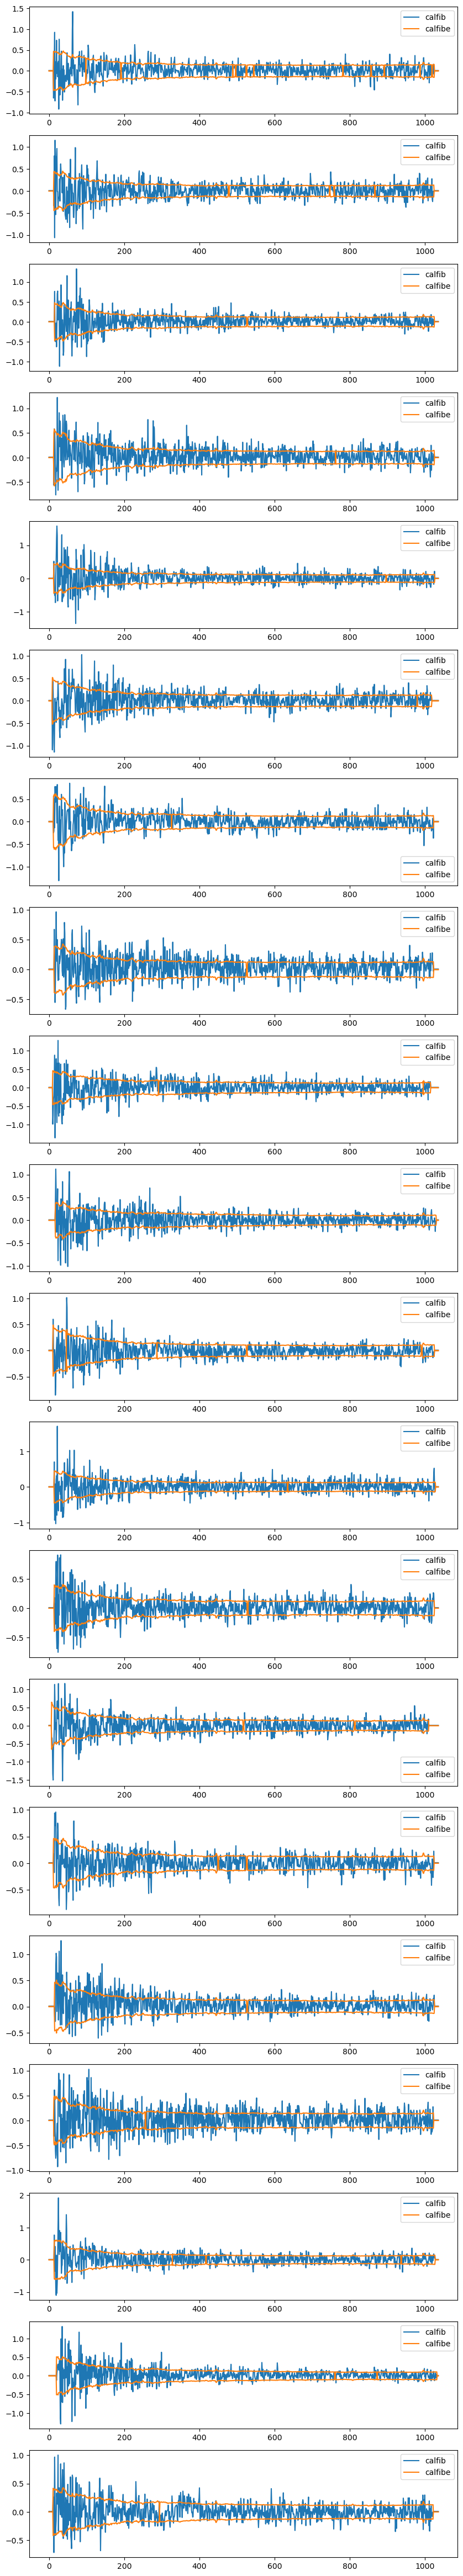

In [3]:
%matplotlib inline
import numpy as np
from matplotlib import pyplot as plt

n_sample = 20
rnd_ind = np.random.randint(0, len(fibs_tab['calfib']), n_sample)
fig, ax = plt.subplots(n_sample, 1, figsize=(10, n_sample*3))

for i in range(n_sample):
    ax[i].plot(fibs_tab['calfib'][rnd_ind[i]], label='calfib')
    ax[i].plot(fibs_tab['calfibe'][rnd_ind[i]], label='calfibe')
    ax[i].plot(-fibs_tab['calfibe'][rnd_ind[i]], color='C1', label=None)
    ax[i].legend()
    

## Comapre cov and API noise:

In [8]:
cov = np.cov(fibs_tab['calfib'], rowvar=False)
cov_api = np.diag(np.mean(fibs_tab['calfibe'], axis=0)**2)


Text(0, 0.5, 'Mean COV_API/COV - 1 shot')

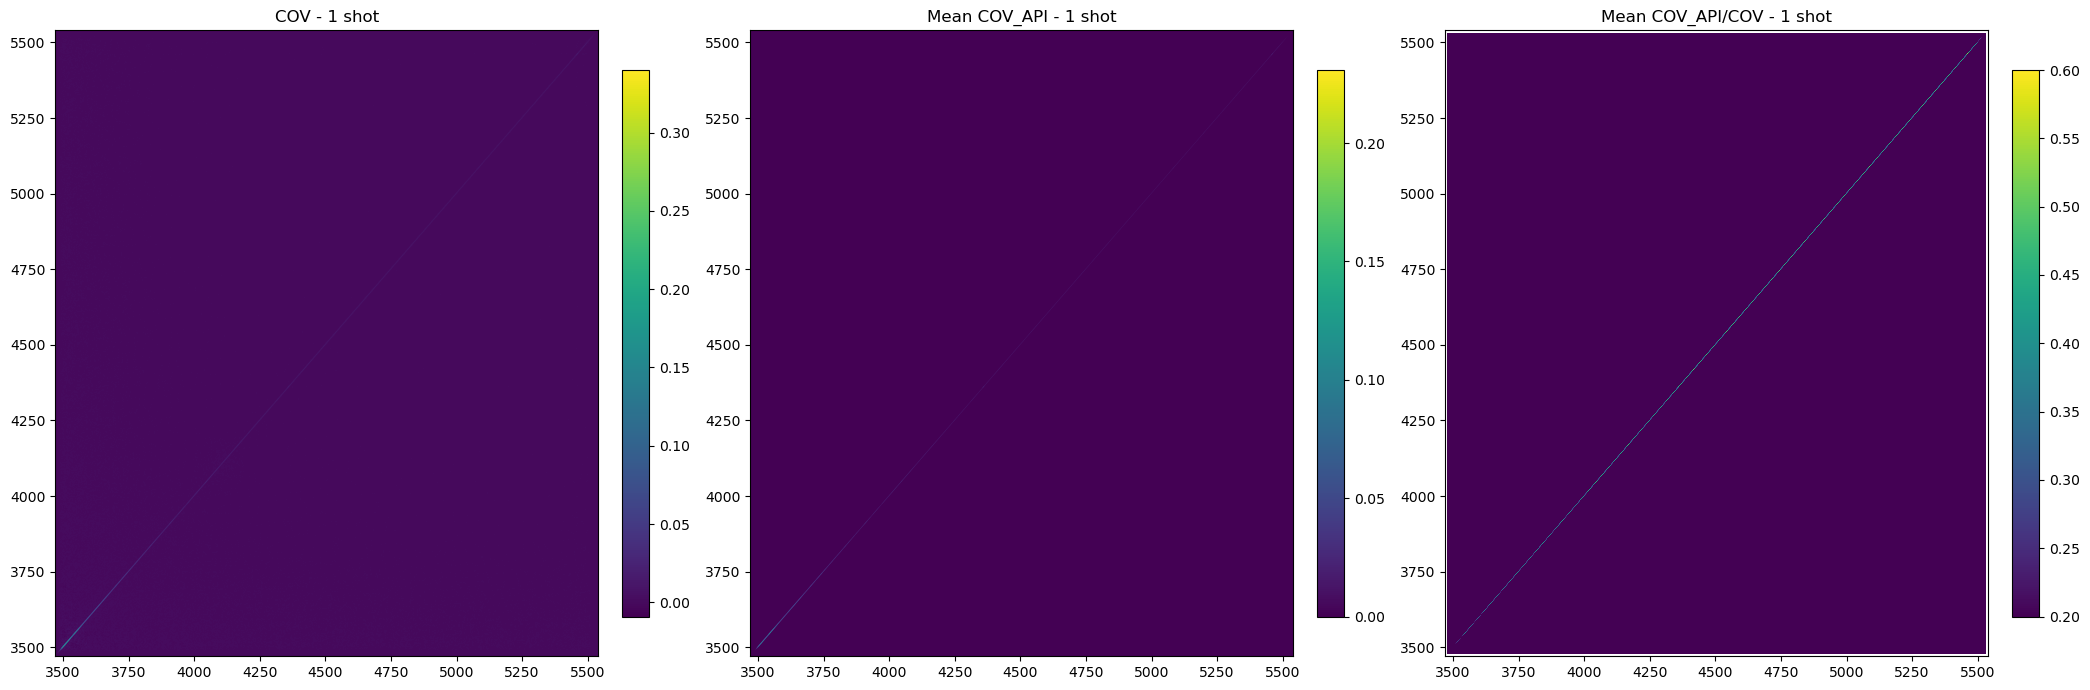

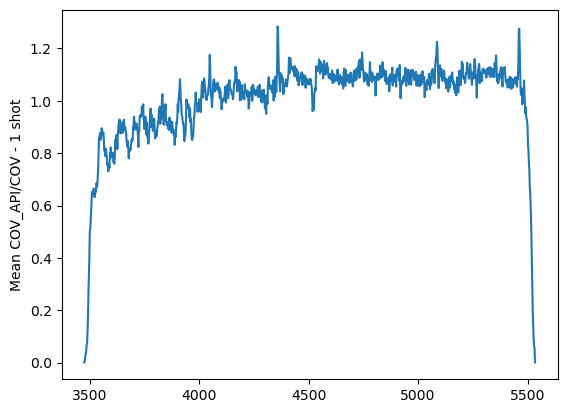

In [56]:
%matplotlib inline
import h5py
from matplotlib import pyplot as plt
with h5py.File('/home/jovyan/work/hetdex/data/wave.h5', 'r') as f:
    wave = f['wave'][:]
    
fig, ax = plt.subplots(1,3, figsize=(21,7)) 
im0 = ax[0].imshow(cov[ :, :], origin='lower', cmap='viridis',
                    aspect='auto', extent=[wave[0], wave[-1], wave[0], wave[-1]])
im1 = ax[1].imshow(cov_api, origin='lower', cmap='viridis',
                    aspect='auto', extent=[wave[0], wave[-1], wave[0], wave[-1]])
im2 = ax[2].imshow(cov_api/cov , origin='lower', cmap='viridis',
                    aspect='auto', extent=[wave[0], wave[-1], wave[0], wave[-1]], vmin=0.2, vmax=0.6)
ax[0].set_title(f'COV - 1 shot')
ax[1].set_title(f'Mean COV_API - 1 shot')
ax[2].set_title(f'Mean COV_API/COV - 1 shot')

fig.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)
fig.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)
fig.colorbar(im2, ax=ax[2], fraction=0.046, pad=0.04)
fig.tight_layout()

fig, ax = plt.subplots()
ax.plot(wave, np.diag(cov_api)/np.diag(cov))
ax.set_ylabel('Mean COV_API/COV - 1 shot')


In [31]:
cov_api[np.arange(1036), np.arange(1036)]/cov[np.arange(1036), np.arange(1036)]

array([       nan,        nan, 0.00034084, ...,        nan,        nan,
              nan])

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 1.68625387e-05, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00]])

### Direct Cov Combine more spectra :

In [ ]:

for c, i in enumerate(np.arange(-1, -20, -1)):
    fibs_tab = fibs.get_fibers_one_shot(fibs.shotids_list[i], keep_calfibe=True)
    if c ==0:
        calfibs = fibs_tab['calfib'][:]
        calfibse = fibs_tab['calfibe'][:]
    else:
        calfibs = np.vstack([calfibs, fibs_tab['calfib'][:]])
        calfibse = np.vstack([calfibse, fibs_tab['calfibe'][:]])
        

In [ ]:
print(f'total fiber counts {calfibs.shape[0]}')
    

In [ ]:
cov = np.cov(calfibs, rowvar=False)

In [ ]:
%matplotlib inline
import h5py
from matplotlib import pyplot as plt
with h5py.File('/home/jovyan/work/hetdex/data/wave.h5', 'r') as f:
    wave = f['wave'][:]
    
fig, ax = plt.subplots(1,3, figsize=(21,7)) 
im0 = ax[0].imshow(cov[ :, :], origin='lower', cmap='viridis',
                    aspect='auto', extent=[wave[0], wave[-1], wave[0], wave[-1]])
im1 = ax[1].imshow(cov[ :, :] - np.diag(np.mean(calfibes, axis=0)**2), origin='lower', cmap='viridis',
                    aspect='auto', extent=[wave[0], wave[-1], wave[0], wave[-1]])
im1 = ax[1].imshow(cov[ :, :] / np.diag(np.mean(calfibes, axis=0)**2) , origin='lower', cmap='viridis',
                    aspect='auto', extent=[wave[0], wave[-1], wave[0], wave[-1]])
fig.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)
fig.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)
fig.tight_layout()
